# Goals

- Practice loading and working with data using Pandas and Numpy
- Practice training a logistic regression model in scikit-learn
- Do a basic evaluation of a machine learning model
- Interpret a logistic regression model by visualizing its weights
- Train a basic neural network using scikit-learn
- Practice doing hyperparameter selection 
- Generate LIME explanations using a software package
- Use LIME explanations to interpret logistic regression and neural network models and reason about their behavior


In [1]:
import pandas as pd
import numpy as np

/var/folders/59/kb315h4121n8mknx9yhv95br0000gn/T/ipykernel_900/2162656668.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Practice loading data in Pandas

Read in the the data in grades_dataset.csv as a Pandas dataframe.

Save the labels in column 'Grade>90' as a numpy array and name it 'y'  Use the label_names included below as the names for the 2 classes (just don't delete this line, your code will use it later).

Save the names of all of the other columns as a numpy array named feature_names.  Save the data in those columns as a numpy array named X.

In [2]:
# Reading data
data = pd.read_csv('grades_dataset.csv')

# Saving labels into column
y = data['Grade>90'].values

label_names = [ 'Grade<=90' , 'Grade>90' ] ##Don't delete this

# Saves names of all other columns
feature_names = data.columns.drop('Grade>90').values

# Saving data from the columns 
x = data.drop('Grade>90', axis = 1).values



## Practice preprocessing data 

Generate 3 sets of indices corresponding to the train, valid and test sets.  The train set should be 60% of the data, the valid set should be 20% of the data and the test set should also be 20% of the data.  These sets should be random and shouldn't overlap.  Generate them by using scikit-learn's train_test_split function twice -- first to split out the test set, then to split the remaining indices into the train and valid set.  

Then scale the data using scikit-learn's StandardScaler.  You should fit the scaler on the train set only, then scale all of the data using it.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Splitting data into train + valid(80% of data) and test(%20 of the data)
x_train_valid, x_test, y_train_valid, y_test = train_test_split(x, y, test_size=0.2, random_state = 7)

# Splitting train + valid set into just train(60%) and valid(20%)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_valid, y_train_valid, test_size=0.25, random_state=7 )

# scale data 
scaler = StandardScaler()

# fit scalar to only training set
scaler.fit(x_train)

# scale remaining data
x_train_scaled = scaler.transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

## Practice training a logistic regression model in scikit-learn

Train a scikit-learn logistic regression model on the training dataset.  Use the default parameters.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# initializing the LogisticRegression model
log_reg = LogisticRegression()

# fit logistic regression model into train dataset
log_reg.fit(x_train_scaled, y_train)

LogisticRegression()

## Do a basic evaluation of a machine learning model

Write a function named print_model_evaluation with the function signature below.  Your function should print performance metrics for a model on both the train and the test set.  Your function should have the signature given to you in the code block below.

The 3 metrics your function should print are:
- The fraction of positive labels in the dataset (try the numpy mean function)
- The accuracy of the model (use the scikit-learn function)
- The AUC score of the model (use the scikit-learn function)

Your print statements should indicate what is being printed (i.e. Train accuracy: ...)

Call your function on the model you trained in the previous step.

In [6]:
from sklearn.metrics import accuracy_score, roc_auc_score
import numpy as np

def print_model_evaluation(model, x_train, y_train, x_test, y_test):
    # Printing the fraction of positive labels in the dataset using numpy mean
    print(f"Fraction of positive labels in train set: {np.mean(y_train == 1):.2f}")
    print(f"Fraction of positive labels in test set: {np.mean(y_test == 1):.2f}")
    
    # Accuracy of the model using scikit-learn function
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
    print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
    
    # AUC score of model
    y_train_prob = model.predict_proba(x_train)[:, 1]
    y_test_prob = model.predict_proba(x_test)[:, 1]
    print(f"Train AUC: {roc_auc_score(y_train, y_train_prob):.2f}")
    print(f"Test AUC: {roc_auc_score(y_test, y_test_prob):.2f}")
    
print_model_evaluation(log_reg, x_train_scaled, y_train, x_test_scaled, y_test)
    

Fraction of positive labels in train set: 0.50
Fraction of positive labels in test set: 0.50
Train Accuracy: 0.55
Test Accuracy: 0.56
Train AUC: 0.56
Test AUC: 0.56


## Interpret a logistic regression model by visualizing its weights

Write a function called plot_model_weights that has the function signature below.  Your function should make and show a bar plot of the model weights passed into it, and label them with the corresponding feature names.  You should title the figure "Model Weights" and title the y-axis "Feature Weight"

Here's an example of the format your plot should have (from a different dataset):

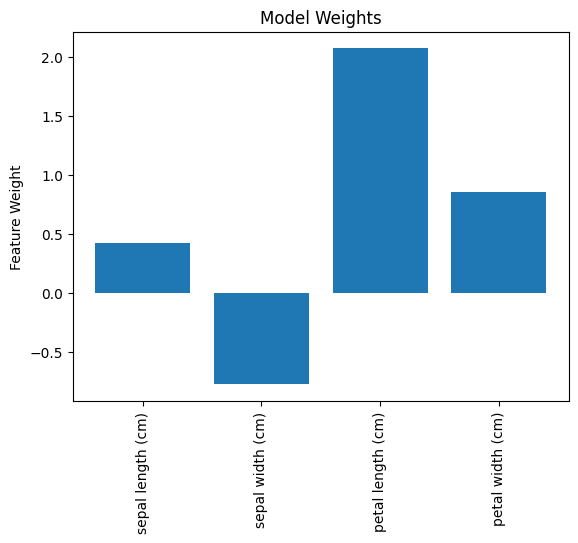

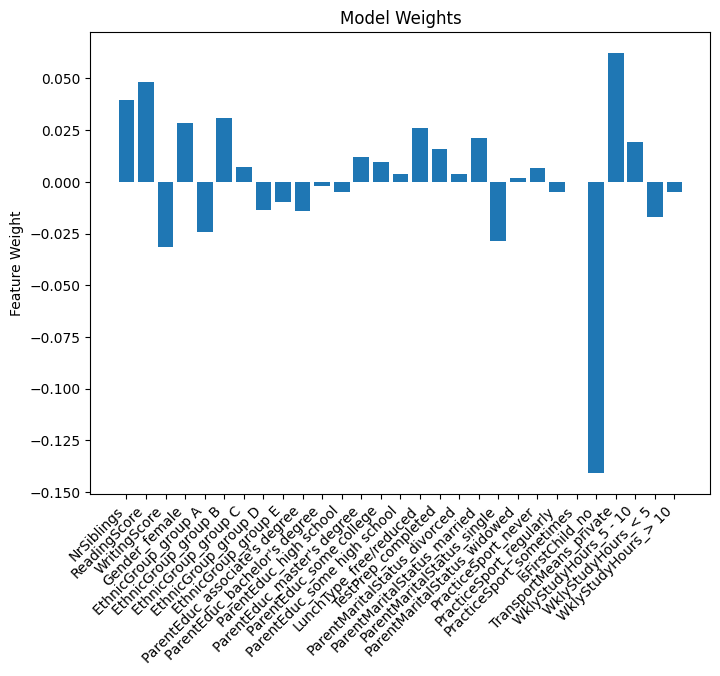

In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_weights(model, feature_names):
    # Coefficients
    weights = model.coef_[0]
    
    # Bar plot
    plt.figure(figsize=(8,6))
    plt.bar(np.arange(len(weights)), weights, tick_label=feature_names)
    
    # Title & labels
    plt.title("Model Weights")
    plt.ylabel("Feature Weight")
    
    # Feature names on x-axis are rotated
    plt.xticks(rotation=45, ha ='right')
    
    # Show plot
    plt.show()

plot_model_weights(log_reg, feature_names)

### Writing prompt 1: Explain how this model works in 1-3 sentences.  


This model works by utilizing a linear combination of features that are input and their coeffecients in order to predict probability of a binary outcome(0 or 1). Maps result to a probability between 0 and 1 using the logistic function(sigmoid function), and the model classifies input into of the two classes using a threshold.

## Practice using and interpreting a LIME explanation from a software package

Use the LimeTabularExplainer in lime_tabular to generate explanations for 10 randomly selected test instances.  Consider using numpy's random.choice function to choose the 10 random instances.  Make sure to save them as a list so you can use them in the next step!

To use the LIME package, read through the documentation here: https://lime-ml.readthedocs.io/en/latest/lime.html#module-lime.lime_tabular 

Set the num_features to 5, and the num_samples to 50,000

In [ ]:
import numpy as np
import lime 
import lime.lime_tabular
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import random

# initialize LimeTabularExplainer
# Explainer is fit into training data and has the feature names and class names
explainer = lime.lime_tabular.LimeTabularExplainer(x_train_scaled, mode = "classification", feature_names=feature_names, class_names=["Class 0", "Class 1"], discretize_continuous=True)

# 10 randomly selected test instances using numpy's random.choice
np.random.seed(7)
random_indices = np.random.choice(x_test_scaled.shape[0], 10, replace=False)
random_instances = x_test_scaled[random_indices]

# explanations for the instances
explanations = []2
for i, instance in enumerate(random_instances):
    exp = explainer.explain_instance(instance, log_reg.predict_proba, num_features=5, num_samples=50000)
    explanations.append(exp)
    print(f"Explanation for instance {i+1}:")
    exp.show_in_notebook(show_table=True, show_all=False)

### Writing prompt 2:  What do these explanations tell you about how this model works?  Explain your response in 1-3 sentences.


These explanations tell me how this model works by providing information on which features are more important in affecting the predictions of the logistic regression model for individual instances.

### Writing prompt 3:  Explain how you can use these explanations to tell LIME is "working".  Make sure to compare the explanations generated by LIME to the plot of your model's weights to make your argument.  Explain your response in 2-4 sentences.


Lime is "working" because by comparing the feature and their importance generated by LIME with the model's weight plot. Lime's explanations should be similar to the direction and importance of the model's weights for each feature

### Writing prompt 4: Would you use this model?  Do you need additional information to decide?  Explain your response in 2-4 sentences.


I would only use this model if the model's performance like accuracy and AUC score meet the criteria for the problem at hand. However, If presented with unseen data then the additional information I need to use this data is the model's performance on out-of-sample data and interpretability.

## Train a basic neural network and evaluate it

Train a simple neural network on the train dataset.  Use the scikit-learn MLP Classifier.

Set max_iter to 20000.  Otherwise, use default settings.

See the documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html 

Use your print_model_evaluation function to evaluate the model.

In [18]:
from sklearn.neural_network import MLPClassifier

# Initialize MLPClassifier with a max_iter of 20000
mlp_clf = MLPClassifier(max_iter=20000, random_state=7)

# fit model to train dataset
mlp_clf.fit(x_train_scaled, y_train)

# evaluating model
print_model_evaluation(mlp_clf, x_train_scaled, y_train, x_test_scaled, y_test)

Fraction of positive labels in train set: 0.50
Fraction of positive labels in test set: 0.50
Train Accuracy: 0.97
Test Accuracy: 0.80
Train AUC: 1.00
Test AUC: 0.86


## Practice Doing Hyperparameter Selection

Run a hyperparameter search for your neural network where you try different hyperparameters: in this case, numbers and sizes of hidden layers.  You should measure which set of hyperparameters "works best," i.e. has the highest AUC score on the validation set.  Use the best set of hyperparameters to train and evaluate a second neural network model using the print_model_evaluation function.

For all of the models you try, you should set max_iter to 20000.  Try all of the following hidden layer sizes as your hyperparameters:
- 1 hidden layer of size 10  -- hidden_layer_sizes=( 10 )
- 1 hidden layer of size 20 -- hidden_layer_sizes=( 20 )
- 2 hidden layers: the first of size 10 and the second of size 20 -- hidden_layer_sizes=( 10 , 20 )
- 3 hidden layers: the first of size 10, the second of size 20, and the third of size 10 -- hidden_layer_sizes=( 10 , 20 , 20 )


In [20]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

# list of different hidden layers
hidden_layer_configs = [(10,), (20,), (10, 20), (10, 20, 30)]

# variable for storing best model and its auc 
best_model = None
best_auc = 0
best_config = None

# iterating
for config in hidden_layer_configs:
    print(f"Training with hidden_layer_sizes={config}")
    # MLPClassifier with current hidden layers
    mlp_clf = MLPClassifier(hidden_layer_sizes=config, max_iter=20000, random_state=7)
    
    # training model on training set
    mlp_clf.fit(x_train_scaled, y_train)
    
    # Predict probabilities for validation set
    y_valid_prob = mlp_clf.predict_proba(x_valid_scaled)[:, 1] # Class 1 Probability
    
    # Calculate AUC for val set
    auc_score = roc_auc_score(y_valid, y_valid_prob)
    print(f"Validation AUC: {auc_score:.4f}")
    
    # Update best model based on AUC
    if auc_score > best_auc:
        best_auc = auc_score
        best_model = mlp_clf
        best_config = config

# Print best config. and val. AUC
print(f"Best hidden_layer_sizes={best_config} with Validation AUC={best_auc:.4f}") 

# evaluate best model
print_model_evaluation(best_model, x_train_scaled, y_train, x_test_scaled, y_test)

Training with hidden_layer_sizes=(10,)
Validation AUC: 0.8964
Training with hidden_layer_sizes=(20,)
Validation AUC: 0.8962
Training with hidden_layer_sizes=(10, 20)
Validation AUC: 0.9127
Training with hidden_layer_sizes=(10, 20, 30)
Validation AUC: 0.9127
Best hidden_layer_sizes=(10, 20, 30) with Validation AUC=0.9127
Fraction of positive labels in train set: 0.50
Fraction of positive labels in test set: 0.50
Train Accuracy: 0.90
Test Accuracy: 0.84
Train AUC: 0.96
Test AUC: 0.90


### Writing prompt 5: How does your best model here compare to the first model you trained with 1 hidden layer of size 10?  Do you think it's worth it to do a hyperparameter search?  Will you do one in the future?  Respond in 2-4 sentences.


My best model here outperformed my first model, so it worth it to do a hyperparameter search. I would do one in the future in order to refine model performance and make sure its adaptibility is proficient enough for any needs of the dataset.

## Practice choosing your own hyperameters

Do a research and come up with another set of hyperparameters to try (consider changing the activation, or trying more variations on hidden layer sizes).  Report the results of your new hyperparameter search.


In [21]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

# list of hyperparameter combinations 
hyperparameter_configs = [
    {'hidden_layer_sizes': (30,), 'activation': 'relu'},       # One hidden layer of 30 units with relu
    {'hidden_layer_sizes': (50, 30), 'activation': 'tanh'},    # Two hidden layers with 50 and 30 units, tanh activation
    {'hidden_layer_sizes': (50, 30, 20), 'activation': 'relu'}, # Three hidden layers, relu activation
    {'hidden_layer_sizes': (30,), 'activation': 'logistic'},   # One hidden layer of 30 units with logistic activation
    {'hidden_layer_sizes': (50, 30, 20), 'activation': 'tanh'}  # Three hidden layers with tanh activation
]

# storing best model and AUC score
best_model = None
best_auc = 0
best_config = None

# Iterate over hyperparameter configurations
for config in hyperparameter_configs:
    print(f"Training with hidden_layer_sizes={config['hidden_layer_sizes']} and activation={config['activation']}")
    
    # Initializing the MLPClassifier with the current hyperparameters
    mlp_clf = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'], 
        activation=config['activation'], 
        max_iter=20000, 
        random_state=42
    )
    
    # Training model on training set
    mlp_clf.fit(x_train_scaled, y_train)
    
    # probabilities for the validation set
    y_valid_prob = mlp_clf.predict_proba(x_valid_scaled)[:, 1]  # Probabilities for class 1
    
    # Calculate the AUC score for the validation set
    auc_score = roc_auc_score(y_valid, y_valid_prob)
    print(f"Validation AUC: {auc_score:.4f}")
    
    # Update the best model if the current model has a higher AUC
    if auc_score > best_auc:
        best_auc = auc_score
        best_model = mlp_clf
        best_config = config

# Output the best configuration and its validation AUC
print(f"Best config: hidden_layer_sizes={best_config['hidden_layer_sizes']}, activation={best_config['activation']} with Validation AUC={best_auc:.4f}")

# Use the print_model_evaluation function to evaluate the best model
print_model_evaluation(best_model, x_train_scaled, y_train, x_test_scaled, y_test)

Training with hidden_layer_sizes=(30,) and activation=relu
Validation AUC: 0.8920
Training with hidden_layer_sizes=(50, 30) and activation=tanh
Validation AUC: 0.8694
Training with hidden_layer_sizes=(50, 30, 20) and activation=relu
Validation AUC: 0.8560
Training with hidden_layer_sizes=(30,) and activation=logistic
Validation AUC: 0.8914
Training with hidden_layer_sizes=(50, 30, 20) and activation=tanh
Validation AUC: 0.8480
Best config: hidden_layer_sizes=(30,), activation=relu with Validation AUC=0.8920
Fraction of positive labels in train set: 0.50
Fraction of positive labels in test set: 0.50
Train Accuracy: 0.88
Test Accuracy: 0.81
Train AUC: 0.94
Test AUC: 0.89


## Writing prompt 6: How does your best model compare to your previous best model?  What does this tell you about your choice of hyperparameters?  Respond in 2-4 sentences.

The best model compares to the previous best model by having a higher AUC score meaning that it has better classification on the validation set. This tells me that my choice of hyperparameters have better improved learning and convergence.

## Use LIME explanations to interpret a neural network

Repeat the steps to use LIME to explain the best neural network you train (either the one from the first ore second hyperparameter search).  Generate explanations for the same 10 random instances you explained before.

In [ ]:
import numpy as np
import lime
import lime.lime_tabular

# Initialize the LimeTabularExplainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    x_train_scaled,  # Training data
    mode="classification",
    feature_names=feature_names,  # Feature names
    class_names=["Class 0", "Class 1"],  # Class names (binary classification)
    discretize_continuous=True
)

# Reuse the 10 random test instances from before
np.random.seed(42)  # Ensure consistency
random_instances = x_test_scaled[random_indices]

# Generate LIME explanations for the best model (neural network) on the same 10 random instances
for i, instance in enumerate(random_instances):
    exp = explainer.explain_instance(instance, best_model.predict_proba, num_features=5, num_samples=50000)
    print(f"Explanation for instance {i+1}:")
    exp.show_in_notebook(show_table=True, show_all=False)

### Writing prompt 7: What do these explanations tell you about how this model works?  Respond in 1-3 sentences.

The explanations tell me which featues have the most signficant impact on the neural network's prediction.

### Writing prompt 8: How do these explanations differ from the explanations for the logistic regression model?  Consider how different the explanations are between different instances.  

Neural network model explanations differ from the logistic regression model because the neural networks have the capacity to capture more complex, non-linear relatinship between the features and target. However, logistic regression explanations are more conssistent across instances which is dependent on a fixed relationship between features and the output.

### Writing prompt 9:  Would you use this model?  Do you need additional information to decide?  Make sure to compare this response to the response for the logistic regression model.  Explain your response in 2-5 sentences.

I would consider using this model if it has a better performance than the logistic regression model in AUC score and accuracy. I would also consider this model if the problem at hand is non-liner and complex.

## Extensions: 

Here are a few ideas, but you're highly encouraged to try other ideas!

Some extension ideas:
- Write your own implementation of LIME
- Train another non-linear model (consider a random forest model etc) and use LIME to interpret it.  Make sure to do hyperparameter selection!
- Find your own dataset, process it, and re-run all of this interpretation.  Are your conclusions different?